# GeoAtt-PointNet++ — Evaluasi (Colab) · Multi-SeedRahmat Zulfikri · Magister Teknik Elektro UGMEvaluasi 5 seed × 1 fold dari training (4 varian: no_geom / gam_only / fuse_only / with_geom).**Metrik utama (identifikasi 1:N — sesuai tugas tesis):** Rank-1, Rank-5, Rank-10, mAP, CMC, confusion matrix.**Metrik sekunder (verifikasi 1:1):** EER, AUC, TAR@FAR — dihitung untuk perbandingan tradisional.**Output:**- `eval_results/with_geom/<ts>/results_seed_<S>.json` — metrik per seed (termasuk `test_fingerprint`)- `eval_results/with_geom/<ts>/embeddings_seed_<S>.npz` — gallery+probe embeddings (untuk McNemar di compare.ipynb)- `eval_results/with_geom/<ts>/cmc_curve.png`, `confusion_matrix_seed_<S>.png`, `tsne_seed_<S>.png`, dst.

## 1. Setup & Import

In [1]:
# ── Mount Google Drive ────────────────────────────────────────────────────────from google.colab import drivedrive.mount('/content/drive')!pip install torch torchvision numpy scikit-learn matplotlib -qimport sysimport osfrom datetime import datetimefrom pathlib import Path# Root proyek di Google Drive — sesuaikan jika struktur folder berbedaPROJECT_ROOT = Path('/content/drive/MyDrive/3DCNN')if str(PROJECT_ROOT) not in sys.path:    sys.path.insert(0, str(PROJECT_ROOT))# Timestamp eksekusi — digunakan untuk memisahkan hasil tiap runEXPERIMENT_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')import jsonimport numpy as npimport torchfrom torch.utils.data import DataLoaderimport matplotlibimport matplotlib.pyplot as pltmatplotlib.rcParams['figure.dpi'] = 120# Device: Colab biasanya punya GPU CUDAif torch.cuda.is_available():    DEVICE = torch.device("cuda")else:    DEVICE = torch.device("cpu")print(f"Device  : {DEVICE}")print(f"PyTorch : {torch.__version__}")print(f"Project : {PROJECT_ROOT}")print(f"Timestamp: {EXPERIMENT_TIMESTAMP}")# ── Auto-detect GPU VRAM / RAM → BATCH_SIZE / NUM_WORKERS / N_POINTS / COMPILE ─def _auto_config():    """    Deteksi GPU memory, CPU cores, dan system RAM → return config optimal.    """    import os, subprocess    # CPU cores    try:        n_cpu = os.cpu_count() or 2    except Exception:        n_cpu = 2    # System RAM (GB)    try:        with open('/proc/meminfo') as f:            for line in f:                if line.startswith('MemTotal:'):                    sys_ram_gb = int(line.split()[1]) / (1024 ** 2)                    break            else:                sys_ram_gb = 16    except Exception:        sys_ram_gb = 16    # GPU VRAM (MB)    try:        out = subprocess.check_output(            ['nvidia-smi', '--query-gpu=memory.total', '--format=csv,noheader,nounits'],            text=True        )        vram_mb = int(out.strip().split('\n')[0])    except Exception:        vram_mb = 0    vram_gb = vram_mb / 1024    # Heuristic config    if vram_gb >= 75:          # A100 80GB / H100        bs, nw, lr, flr = 512, min(8, n_cpu), 2e-3, 2e-4        n_pts = 8192           # VRAM besar → bisa 2x point density        use_c = True           # torch.compile worth it di A100        label = 'A100/H100 class'    elif vram_gb >= 35:        # A100 40GB        bs, nw, lr, flr = 384, min(8, n_cpu), 2e-3, 2e-4        n_pts = 8192        use_c = True        label = 'A100 40GB'    elif vram_mb > 0:          # T4 / L4 / V100 16-24GB        bs, nw, lr, flr = 128, min(2, n_cpu), 1e-3, 1e-4        n_pts = 4096        use_c = False        label = 'T4/L4/V100 class'    else:                      # CPU        bs, nw, lr, flr = 32, 0, 1e-3, 1e-4        n_pts = 2048        use_c = False        label = 'CPU'    # Preload augment: worth it kalau RAM besar (hemat CPU, percepat training)    # Estimasi RAM per item: N_POINTS × 6 dim × 4 byte ≈ N_POINTS × 24 byte    # 1100 frame × repeat(20) × 8192 × 24 B ≈ 4.3 GB — masih sangat aman    preload = (sys_ram_gb >= 32) and (vram_gb >= 16)    # FRAME_REPEAT: lebih tinggi kalau RAM besar & preload aktif    # Dengan preload, repeat tinggi nggak lambatin training (sudah di-RAM)    if preload and sys_ram_gb >= 128:        repeat = 30    elif preload and sys_ram_gb >= 64:        repeat = 20    else:        repeat = 10    print(f'GPU detect : {label} | VRAM={vram_gb:.1f}GB | CPU={n_cpu} core | RAM={sys_ram_gb:.1f}GB')    print(f'Auto-config: BATCH_SIZE={bs}, NUM_WORKERS={nw}, N_POINTS={n_pts}, FRAME_REPEAT={repeat}')    print(f'             LR={lr}, FINETUNE_LR={flr}, torch.compile={use_c}')    print(f'Preload augment: {preload}')    return bs, nw, lr, flr, n_pts, use_c, preload, repeat_AUTO_BS, _AUTO_NW, _AUTO_LR, _AUTO_FLR, _AUTO_N_PTS, _AUTO_COMPILE, _AUTO_PRELOAD, _AUTO_REPEAT = _auto_config()# ── Helper: variant name ──────────────────────────────────────────────────────def _get_variant(use_gam, use_geom_fusion):    if use_gam and use_geom_fusion:        return 'with_geom'    elif use_gam and not use_geom_fusion:        return 'gam_only'    elif not use_gam and use_geom_fusion:        return 'fuse_only'    else:        return 'no_geom'

Mounted at /content/drive
Device  : cuda
PyTorch : 2.10.0+cu128
Project : /content/drive/MyDrive/3DCNN
Timestamp: 20260516_223830
GPU detect : A100/H100 class | VRAM=95.6GB | CPU=48 core | RAM=176.9GB
Auto-config: BATCH_SIZE=512, NUM_WORKERS=8, N_POINTS=8192, FRAME_REPEAT=30
             LR=0.002, FINETUNE_LR=0.0002, torch.compile=True
Preload augment: True


In [2]:
# PATCH: Handle checkpoint dari torch.compile (PyTorch 2.0+)# torch.compile menyimpan key dengan prefix '_orig_mod.' — strip saat load.# Jalankan cell ini SEKALI sebelum evaluasi. Nggak perlu retrain.import torch_orig_load = torch.loaddef _patched_load(*args, **kwargs):    ckpt = _orig_load(*args, **kwargs)    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:        state = ckpt['model_state_dict']        if any(k.startswith('_orig_mod.') for k in state.keys()):            ckpt['model_state_dict'] = {k.replace('_orig_mod.', '', 1): v for k, v in state.items()}            print("[torch.compile patch] Prefix '_orig_mod.' dihapus ✅")    return ckpttorch.load = _patched_loadprint('[torch.compile patch] Aktif.')

[torch.compile patch] Aktif.


In [3]:
# Import modules projectfrom models.siamese import SiamesePalmNetfrom utils.dataset import (    PalmPairDataset,    scan_dataset_frames,    balance_label_frames,    generate_pairs,    load_session,    _sample_points,    GEOMETRY_DIM,)from utils.metrics import (    compute_all_metrics,    compute_eer,    compute_dprime,    compute_tar_at_far,    plot_roc,    plot_det,    plot_similarity_dist,    plot_tsne,    print_metrics_table,    # Identifikasi & statistik (ditambahkan untuk thesis)    compute_cmc_curve,    compute_rank_n,    compute_map,    test_set_fingerprint,)from utils.normalizer import GeometryNormalizerfrom evaluate import load_model, run_inference, evaluate_model, _is_frame_layoutfrom utils.enrollment import GalleryEnroller, query_similarityprint(f"GEOMETRY_DIM = {GEOMETRY_DIM}")print("Import berhasil.")

GEOMETRY_DIM = 14
Import berhasil.


## 2. Konfigurasi

In [4]:
# ============================================================# KONFIGURASI — auto-detect run terbaru + multi-seed# ============================================================DATA_DIR = PROJECT_ROOT / 'dataset'USE_GEOM = True# ── Auto-detect timestamp training terbaru ────────────────────────────────────TRAIN_TIMESTAMP = None  # mis. '20260510_103000' atau None untuk auto-latestRUNS_DIR = PROJECT_ROOT / 'runs' / 'with_geom'if TRAIN_TIMESTAMP is None:    candidates = [d for d in RUNS_DIR.iterdir() if d.is_dir()] if RUNS_DIR.exists() else []    candidates_with_seeds = [d for d in candidates if (d / 'seeds.json').exists()]    if candidates_with_seeds:        train_run_dir = max(candidates_with_seeds, key=lambda p: p.name)        TRAIN_TIMESTAMP = train_run_dir.name    elif candidates:        train_run_dir = max(candidates, key=lambda p: p.name)        TRAIN_TIMESTAMP = train_run_dir.name    else:        train_run_dir = RUNS_DIR / 'PLACEHOLDER'        TRAIN_TIMESTAMP = 'PLACEHOLDER'else:    train_run_dir = RUNS_DIR / TRAIN_TIMESTAMP# ── Load daftar seed dari seeds.json (jika ada) ───────────────────────────────seeds_json = train_run_dir / 'seeds.json'if seeds_json.exists():    with open(seeds_json) as f:        meta = json.load(f)    SEEDS = meta.get('seeds', [42])    SPLIT_SEED = meta.get('split_seed', 42)    print(f"seeds.json ditemukan: {len(SEEDS)} seed → {SEEDS}")else:    SEEDS = [42]    SPLIT_SEED = 42    print(f"⚠️  seeds.json tidak ditemukan di {train_run_dir}. Default ke single seed [42].")# ── Bangun mapping checkpoint per seed ────────────────────────────────────────# Layout baru: runs/with_geom/<ts>/seed_<S>/best.pthCHECKPOINTS = {}for s in SEEDS:    ckpt_path = train_run_dir / f'seed_{s}' / 'best.pth'    CHECKPOINTS[f'seed_{s}'] = str(ckpt_path)# ── Output ────────────────────────────────────────────────────────────────────OUTPUT_DIR = PROJECT_ROOT / 'eval_results' / 'with_geom' / EXPERIMENT_TIMESTAMPOUTPUT_DIR.mkdir(parents=True, exist_ok=True)BATCH_SIZE       = _AUTO_BS * 2  # eval: 2× train batch (auto-detect)NUM_WORKERS      = _AUTO_NW  # auto-detect dari jumlah CPU coreN_POINTS         = _AUTO_N_PTS  # auto-detect (T4=4096, A100=8192)SAMPLING         = "random"SAVE_SCORES      = Falseprint()print(f"EVAL_TIMESTAMP  : {EXPERIMENT_TIMESTAMP}")print(f"TRAIN_TIMESTAMP : {TRAIN_TIMESTAMP}")print(f"DATA_DIR        : {DATA_DIR}")print(f"OUTPUT_DIR      : {OUTPUT_DIR}")print(f"USE_GEOM        : {USE_GEOM}")print(f"SPLIT_SEED      : {SPLIT_SEED}")print(f"SEEDS           : {SEEDS}")print(f"Checkpoint discovery:")for name, path in CHECKPOINTS.items():    status = '✓' if Path(path).exists() else '✗ MISSING'    print(f"  {status}  {name:<10} → {path}")

seeds.json ditemukan: 5 seed → [42, 123, 2026, 7, 31337]

EVAL_TIMESTAMP  : 20260516_223830
TRAIN_TIMESTAMP : 20260516_210959
DATA_DIR        : /content/drive/MyDrive/3DCNN/dataset
OUTPUT_DIR      : /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830
USE_GEOM        : True
SPLIT_SEED      : 42
SEEDS           : [42, 123, 2026, 7, 31337]
Checkpoint discovery:
  ✓  seed_42    → /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_42/best.pth
  ✓  seed_123   → /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_123/best.pth
  ✓  seed_2026  → /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_2026/best.pth
  ✓  seed_7     → /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_7/best.pth
  ✓  seed_31337 → /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_31337/best.pth


## 3. Load Dataset

In [5]:
# Load test split dari training run (splits.json)splits_path = train_run_dir / 'splits.json'if not splits_path.exists():    raise FileNotFoundError(        f"splits.json tidak ditemukan di {splits_path}.\n"        f"Jalankan train.ipynb terlebih dahulu untuk menghasilkan splits.json."    )with open(splits_path) as f:    splits_data = json.load(f)test_frames = {    label: [Path(p) for p in paths]    for label, paths in splits_data['test'].items()}# Verifikasi SPLIT_SEED konsisten dengan training runif splits_data.get('split_seed') != SPLIT_SEED:    print(f"⚠️  SPLIT_SEED mismatch: splits.json={splits_data.get('split_seed')}, "          f"config={SPLIT_SEED}. Gunakan nilai dari splits.json.")    SPLIT_SEED = splits_data['split_seed']# Holdout probes — sesi yang dikecualikan dari trainingholdout_probes = {    label: [Path(p) for p in paths]    for label, paths in splits_data.get('holdout_probes', {}).items()}holdout_probe_list = [    (label, fd)    for label, frames in holdout_probes.items()    for fd in frames]n_labels = len(test_frames)n_total  = sum(len(v) for v in test_frames.values())print(f"Subjek          : {n_labels}")print(f"Total test frame: {n_total}")print(f"SPLIT_SEED      : {SPLIT_SEED}")print()print("Distribusi per subjek (test set):")for label, frames in sorted(test_frames.items()):    sessions = len({f.parent.name for f in frames})    print(f"  {label:<15} : {len(frames)} frame ({sessions} sesi)")print()n_hprobe = len(holdout_probe_list)print(f"Holdout probe   : {n_hprobe} frame "      f"({n_hprobe // max(len(holdout_probes), 1)} per subjek, "      f"{len(holdout_probes)} subjek)")

Subjek          : 11
Total test frame: 219
SPLIT_SEED      : 42

Distribusi per subjek (test set):
  aisah           : 20 frame (2 sesi)
  alji            : 20 frame (2 sesi)
  chrys           : 20 frame (2 sesi)
  fadhil          : 20 frame (2 sesi)
  feby            : 20 frame (2 sesi)
  gede            : 20 frame (2 sesi)
  nola            : 20 frame (2 sesi)
  rahmat          : 20 frame (2 sesi)
  reysa           : 19 frame (2 sesi)
  taufik          : 20 frame (2 sesi)
  yanuar          : 20 frame (2 sesi)

Holdout probe   : 33 frame (3 per subjek, 11 subjek)


In [6]:
# ── Load normalizer per seed (HARD ERROR jika hilang) ─────────────────────────def _find_normalizer(ckpt_path: str) -> Path:    candidate = Path(ckpt_path).parent / "normalizer.json"    if not candidate.exists():        raise FileNotFoundError(            f"normalizer.json tidak ditemukan di {candidate}. "            f"Untuk USE_GEOM=True, normalizer WAJIB ada (fit di training). "            f"Jika Anda mengevaluasi run lama tanpa normalizer, set USE_GEOM=False "            f"atau jalankan evaluate_no_geom.ipynb."        )    return candidate# Normalizer default (dari seed pertama) untuk PalmPairDataset verifikasifirst_existing_ckpt = next((p for p in CHECKPOINTS.values() if Path(p).exists()), None)if USE_GEOM and first_existing_ckpt is not None:    norm_path = _find_normalizer(first_existing_ckpt)    normalizer = GeometryNormalizer.load(str(norm_path))    print(f"Normalizer (default): {norm_path}")elif USE_GEOM:    raise FileNotFoundError(        "Tidak ada checkpoint yang ditemukan. Tidak bisa memuat normalizer. "        "Periksa TRAIN_TIMESTAMP dan struktur direktori runs/with_geom/."    )else:    normalizer = None    print("Normalizer  : tidak digunakan (USE_GEOM=False)")# ── Dataset pasangan untuk verifikasi (sekunder) ──────────────────────────────dataset = PalmPairDataset(    label_sessions=test_frames,    n_points=N_POINTS,    sampling=SAMPLING,    augment=None,    normalizer=normalizer,    seed=SPLIT_SEED,)loader = DataLoader(    dataset,    batch_size=BATCH_SIZE,    shuffle=False,    num_workers=NUM_WORKERS,    pin_memory=(DEVICE.type == "cuda"),)genuine_count  = sum(1 for _, _, lbl in dataset.pairs if lbl == 1.0)impostor_count = sum(1 for _, _, lbl in dataset.pairs if lbl == 0.0)print(f"\nTotal pasangan : {len(dataset)}")print(f"  Genuine    : {genuine_count}")print(f"  Impostor   : {impostor_count}")print(f"  Batches    : {len(loader)}")# ── Gallery & Probe untuk identifikasi (session-level split) ──────────────────import randomdef build_gallery_and_probes(test_frames: dict, seed: int = 42) -> tuple:    """    Gallery: rata-rata embedding semua frame dari 1 sesi per label (enrolled).    Probe  : semua frame dari sesi lainnya (1 sesi × 10 frame = 10 probe per subjek).    Split di level sesi (timestamp) agar tidak ada frame leakage.    Returns:        gallery_frame_groups : {label: [frame_dirs]}  — frame untuk gallery enrollment        probe_dirs           : [(true_label, frame_dir)]    """    rng = random.Random(seed)    gallery_frame_groups = {}    probe_dirs = []    for label, frames in test_frames.items():        # Kelompokkan frame per sesi (parent dir = timestamp)        session_map = {}        for f in frames:            ts = f.parent.name  # '20260505_210153'            session_map.setdefault(ts, []).append(f)        sessions = sorted(session_map.keys())        rng.shuffle(sessions)        # Sesi pertama → gallery enrollment (semua frame di-average)        gallery_frame_groups[label] = session_map[sessions[0]]        # Sesi lainnya → probe (tiap frame = 1 probe query)        for ts in sessions[1:]:            for frame_dir in session_map[ts]:                probe_dirs.append((label, frame_dir))    return gallery_frame_groups, probe_dirsgallery_frame_groups, probe_dirs = build_gallery_and_probes(test_frames, seed=SPLIT_SEED)gallery_labels = list(gallery_frame_groups.keys())# ── Test-set fingerprint ──────────────────────────────────────────────────────# Digunakan untuk memverifikasi bahwa evaluate.ipynb dan evaluate_no_geom.ipynb# menggunakan test set yang identik (cek di compare.ipynb).TEST_FINGERPRINT = test_set_fingerprint(probe_dirs, gallery_labels)print(f"\nGallery : {len(gallery_labels)} subjek "      f"({sum(len(v) for v in gallery_frame_groups.values())} frame total, di-average per subjek)")print(f"Probe   : {len(probe_dirs)} frame "      f"({len(probe_dirs) // max(len(gallery_labels), 1)} probe/subjek rata-rata)")print(f"Test fingerprint: {TEST_FINGERPRINT}")print(f"  (HARUS sama di evaluate_no_geom.ipynb untuk perbandingan valid)")

Normalizer (default): /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_42/normalizer.json
Preloading 219 sesi ke memori...
Preload selesai. Total pasangan: 4142

Total pasangan : 4142
  Genuine    : 2071
  Impostor   : 2071
  Batches    : 5

Gallery : 11 subjek (109 frame total, di-average per subjek)
Probe   : 110 frame (10 probe/subjek rata-rata)
Test fingerprint: 34b90906c80ab1eb
  (HARUS sama di evaluate_no_geom.ipynb untuk perbandingan valid)


## 4. Evaluasi Multi-Seed (loop utama)Untuk setiap seed:1. Load checkpoint + normalizer milik seed itu.2. Hitung embedding gallery (1 per subjek) + probe (sisanya).3. **Identifikasi (utama):** Rank-1, Rank-5, Rank-10, mAP, CMC.4. **Verifikasi (sekunder):** EER, AUC, TAR@FAR=1%/0.1%, d-prime.5. Simpan `results_seed_<S>.json` + `embeddings_seed_<S>.npz` (untuk McNemar di compare.ipynb).


Evaluasi : seed_42  (seed=42)
Checkpoint: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_42/best.pth
[torch.compile patch] Prefix '_orig_mod.' dihapus ✅
Checkpoint berhasil dimuat.
Preloading 219 sesi ke memori...
Preload selesai. Total pasangan: 4142


Embedding 219 sesi: 100%|██████████| 1/1 [00:01<00:00,  1.56s/batch]


Similarity distribution plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/seed_42_sim_dist.png


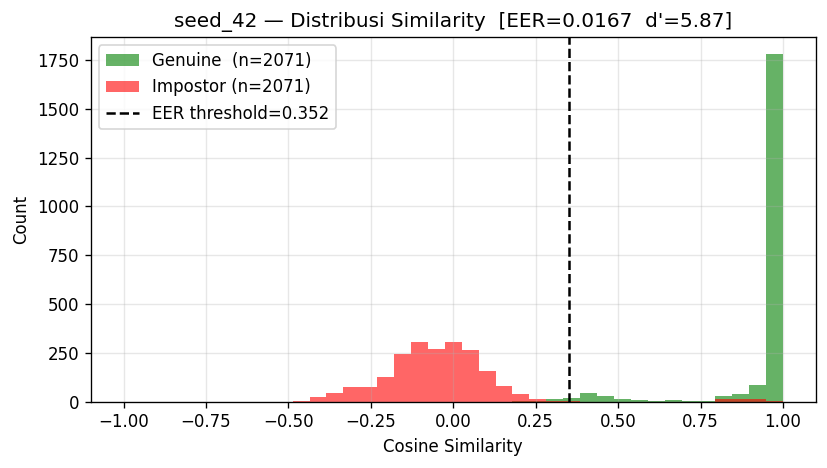


  [IDENTIFIKASI — TEST SPLIT]
    Rank-1   = 0.9636  (106/110)
    Rank-5   = 1.0000
    Rank-10  = 1.0000
    mAP      = 0.9758

  [IDENTIFIKASI — HOLDOUT REAL TEST]
    Rank-1   = 0.9697  (32/33)
    Rank-5   = 1.0000
    mAP      = 0.9798

  [VERIFIKASI — METRIK SEKUNDER]
    EER          = 0.0167
    AUC          = 0.9978
    TAR@FAR=1%   = 0.9054
    d-prime      = 5.871
  Disimpan: results_seed_42.json, embeddings_seed_42.npz

Evaluasi : seed_123  (seed=123)
Checkpoint: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_123/best.pth
[torch.compile patch] Prefix '_orig_mod.' dihapus ✅
Checkpoint berhasil dimuat.
Preloading 219 sesi ke memori...
Preload selesai. Total pasangan: 4142


Embedding 219 sesi: 100%|██████████| 1/1 [00:00<00:00,  3.60batch/s]

Similarity distribution plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/seed_123_sim_dist.png


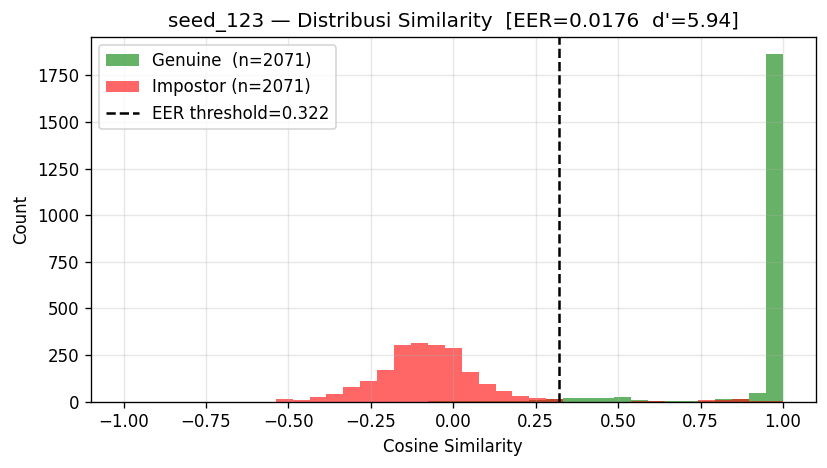


  [IDENTIFIKASI — TEST SPLIT]
    Rank-1   = 0.9636  (106/110)
    Rank-5   = 1.0000
    Rank-10  = 1.0000
    mAP      = 0.9758

  [IDENTIFIKASI — HOLDOUT REAL TEST]
    Rank-1   = 0.9697  (32/33)
    Rank-5   = 1.0000
    mAP      = 0.9798

  [VERIFIKASI — METRIK SEKUNDER]
    EER          = 0.0176
    AUC          = 0.9977
    TAR@FAR=1%   = 0.9281
    d-prime      = 5.937
  Disimpan: results_seed_123.json, embeddings_seed_123.npz

Evaluasi : seed_2026  (seed=2026)
Checkpoint: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_2026/best.pth
[torch.compile patch] Prefix '_orig_mod.' dihapus ✅
Checkpoint berhasil dimuat.
Preloading 219 sesi ke memori...
Preload selesai. Total pasangan: 4142


Embedding 219 sesi: 100%|██████████| 1/1 [00:00<00:00,  3.61batch/s]

Similarity distribution plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/seed_2026_sim_dist.png


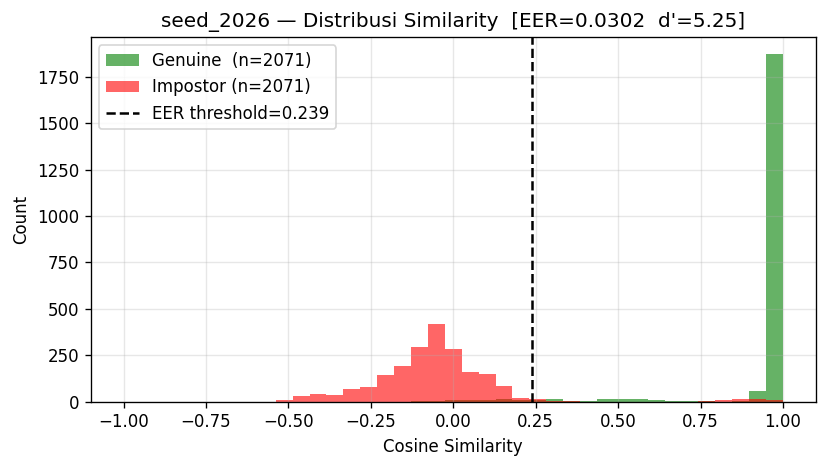


  [IDENTIFIKASI — TEST SPLIT]
    Rank-1   = 0.9636  (106/110)
    Rank-5   = 1.0000
    Rank-10  = 1.0000
    mAP      = 0.9758

  [IDENTIFIKASI — HOLDOUT REAL TEST]
    Rank-1   = 0.9697  (32/33)
    Rank-5   = 1.0000
    mAP      = 0.9798

  [VERIFIKASI — METRIK SEKUNDER]
    EER          = 0.0302
    AUC          = 0.9934
    TAR@FAR=1%   = 0.9319
    d-prime      = 5.252
  Disimpan: results_seed_2026.json, embeddings_seed_2026.npz

Evaluasi : seed_7  (seed=7)
Checkpoint: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_7/best.pth
[torch.compile patch] Prefix '_orig_mod.' dihapus ✅
Checkpoint berhasil dimuat.
Preloading 219 sesi ke memori...
Preload selesai. Total pasangan: 4142


Embedding 219 sesi: 100%|██████████| 1/1 [00:00<00:00,  3.58batch/s]

Similarity distribution plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/seed_7_sim_dist.png


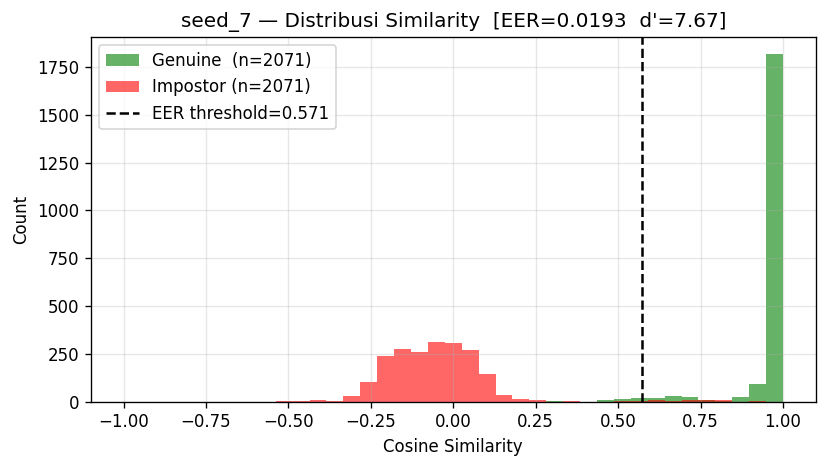


  [IDENTIFIKASI — TEST SPLIT]
    Rank-1   = 0.9727  (107/110)
    Rank-5   = 1.0000
    Rank-10  = 1.0000
    mAP      = 0.9848

  [IDENTIFIKASI — HOLDOUT REAL TEST]
    Rank-1   = 1.0000  (33/33)
    Rank-5   = 1.0000
    mAP      = 1.0000

  [VERIFIKASI — METRIK SEKUNDER]
    EER          = 0.0193
    AUC          = 0.9990
    TAR@FAR=1%   = 0.9469
    d-prime      = 7.674
  Disimpan: results_seed_7.json, embeddings_seed_7.npz

Evaluasi : seed_31337  (seed=31337)
Checkpoint: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seed_31337/best.pth
[torch.compile patch] Prefix '_orig_mod.' dihapus ✅
Checkpoint berhasil dimuat.
Preloading 219 sesi ke memori...
Preload selesai. Total pasangan: 4142


Embedding 219 sesi: 100%|██████████| 1/1 [00:00<00:00,  3.59batch/s]

Similarity distribution plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/seed_31337_sim_dist.png


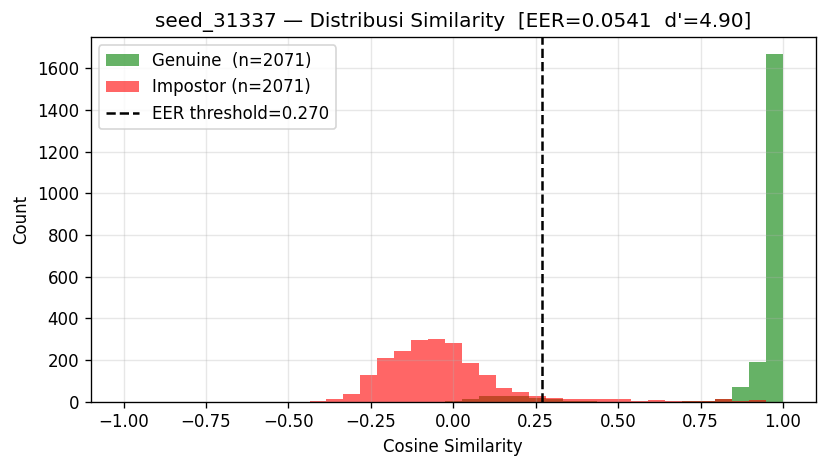


  [IDENTIFIKASI — TEST SPLIT]
    Rank-1   = 0.9273  (102/110)
    Rank-5   = 0.9818
    Rank-10  = 1.0000
    mAP      = 0.9526

  [IDENTIFIKASI — HOLDOUT REAL TEST]
    Rank-1   = 0.9697  (32/33)
    Rank-5   = 0.9697
    mAP      = 0.9747

  [VERIFIKASI — METRIK SEKUNDER]
    EER          = 0.0541
    AUC          = 0.9928
    TAR@FAR=1%   = 0.9314
    d-prime      = 4.904
  Disimpan: results_seed_31337.json, embeddings_seed_31337.npz

Evaluasi 5 seed selesai.
Ringkasan: /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/results.json


In [7]:
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_sim@torch.no_grad()def get_embedding(model, frame_dir: Path, device,                  n_points: int = None, normalizer=None) -> np.ndarray:    """Embedding 128-dim L2-normalized untuk satu frame dir."""    cloud, geom = load_session(frame_dir)    n_pts = n_points if n_points is not None else N_POINTS    pts = _sample_points(cloud, n_pts, method="random")    pts = torch.from_numpy(pts).unsqueeze(0).to(device)    geom_arr = geom.copy()    if normalizer is not None:        geom_arr = normalizer.transform(geom_arr)    geom_t = torch.from_numpy(geom_arr).unsqueeze(0).to(device)    emb = model.encoder(pts, geom_t)    return emb.squeeze(0).cpu().numpy()# ── Gallery Enrollment Strategy ───────────────────────────────────────────────# Pilih strategi: "average" | "weighted" | "median" | "multi"ENROLL_STRATEGY = "multi"   # v0.3.0: multi-prototype k-means (k=3)ENROLL_K = 3enroller = GalleryEnroller(strategy=ENROLL_STRATEGY, k=ENROLL_K)def build_gallery_embeddings(model, gallery_frame_groups, device, n_points, normalizer):    """    Build gallery embeddings dengan strategi enrollment yang dipilih.    Returns:        gallery_dict: {label: embedding (D,) or (k, D)} — bisa single atau multi-prototype    """    gallery_dict = {}    for label, frame_dirs in gallery_frame_groups.items():        embs = np.stack([            get_embedding(model, fd, device, n_points, normalizer)            for fd in frame_dirs        ])        gallery_dict[label] = enroller.enroll(embs, frame_dirs)    return gallery_dict# ── Loop utama: setiap seed ───────────────────────────────────────────────────all_results       = []all_seed_records  = []cmc_results       = {}roc_data          = {}det_data          = {}for model_name, ckpt_path in CHECKPOINTS.items():    seed = int(model_name.replace('seed_', ''))    print(f"\n{'='*64}")    print(f"Evaluasi : {model_name}  (seed={seed})")    print(f"Checkpoint: {ckpt_path}")    print(f"{'='*64}")    # ── Load normalizer milik seed ini ────────────────────────────────────────    if USE_GEOM and Path(ckpt_path).exists():        seed_norm_path = _find_normalizer(ckpt_path)        seed_normalizer = GeometryNormalizer.load(str(seed_norm_path))    else:        seed_normalizer = None    # ── Load model ────────────────────────────────────────────────────────────    if Path(ckpt_path).exists():        model = load_model(ckpt_path, GEOMETRY_DIM, DEVICE, use_geom=USE_GEOM, use_gam=USE_GAM, use_geom_fusion=USE_GEOM_FUSION)        print("Checkpoint berhasil dimuat.")    else:        print(f"[WARN] Checkpoint tidak ditemukan — gunakan bobot acak (hasil tidak bermakna).")        model = SiamesePalmNet(geom_dim=GEOMETRY_DIM, use_geom=USE_GEOM, use_gam=USE_GAM, use_geom_fusion=USE_GEOM_FUSION).to(DEVICE)        model.eval()    # ── (a) Verifikasi via PalmPairDataset (metrik sekunder) ─────────────────    seed_dataset = PalmPairDataset(        label_sessions=test_frames,        n_points=N_POINTS,        sampling=SAMPLING,        augment=None,        normalizer=seed_normalizer,        seed=SPLIT_SEED,    )    seed_loader = DataLoader(        seed_dataset, batch_size=BATCH_SIZE, shuffle=False,        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),    )    verif = evaluate_model(        model=model, loader=seed_loader, device=DEVICE,        model_name=model_name, output_dir=OUTPUT_DIR,        save_scores=SAVE_SCORES, dataset=seed_dataset,    )    all_results.append(verif)    roc_data[model_name] = (verif["labels"], verif["scores"])    det_data[model_name] = (verif["labels"], verif["scores"])    # ── (b) Identifikasi — test split (gallery enrollment + probe) ────────────    gallery_dict = build_gallery_embeddings(        model, gallery_frame_groups, DEVICE, N_POINTS, seed_normalizer)    # Convert ke array untuk compatibility    gallery_labels_list = list(gallery_dict.keys())    gallery_embs_list = [gallery_dict[lbl] for lbl in gallery_labels_list]    rank_positions    = []    probe_true_labels = []    probe_pred_labels = []    probe_embs_list   = []    for true_label, probe_frame_dir in probe_dirs:        probe_emb = get_embedding(model, probe_frame_dir, DEVICE, N_POINTS, seed_normalizer)        probe_embs_list.append(probe_emb)        # Query similarity dengan semua gallery (support multi-prototype)        sims = np.array([            query_similarity(probe_emb, gallery_dict[lbl])            for lbl in gallery_labels_list        ])        ranking = np.argsort(sims)[::-1]        ranked_labels = [gallery_labels_list[i] for i in ranking]        rank_positions.append(ranked_labels.index(true_label) + 1)        probe_true_labels.append(true_label)        probe_pred_labels.append(ranked_labels[0])    probe_embs = np.stack(probe_embs_list)    # Untuk CMC curve, kita perlu gallery dalam format (n_subj, D) rata-rata    gallery_embs_avg = np.stack([        gallery_dict[lbl].mean(axis=0) if gallery_dict[lbl].ndim > 1 else gallery_dict[lbl]        for lbl in gallery_labels_list    ])    rank1      = compute_rank_n(rank_positions, 1)    rank5      = compute_rank_n(rank_positions, 5)    rank10     = compute_rank_n(rank_positions, 10)    map_score  = compute_map(rank_positions)    cmc_curve  = compute_cmc_curve(rank_positions, max_rank=len(gallery_labels_list))    correct_rank1_arr = np.array(        [t == p for t, p in zip(probe_true_labels, probe_pred_labels)], dtype=bool    )    cmc_results[model_name] = {        "cmc":            cmc_curve,        "rank_positions": rank_positions,        "true_labels":    probe_true_labels,        "pred_labels":    probe_pred_labels,        "correct_rank1":  correct_rank1_arr,    }    print(f"\n  [IDENTIFIKASI — TEST SPLIT]")    print(f"    Rank-1   = {rank1:.4f}  ({correct_rank1_arr.sum()}/{len(rank_positions)})")    print(f"    Rank-5   = {rank5:.4f}")    print(f"    Rank-10  = {rank10:.4f}")    print(f"    mAP      = {map_score:.4f}")    # ── (c) Identifikasi — Holdout real test ──────────────────────────────────    holdout_rank_pos   = []    holdout_true_lbls  = []    holdout_pred_lbls  = []    for true_label, probe_frame_dir in holdout_probe_list:        probe_emb = get_embedding(model, probe_frame_dir, DEVICE, N_POINTS, seed_normalizer)        sims = np.array([            query_similarity(probe_emb, gallery_dict[lbl])            for lbl in gallery_labels_list        ])        ranking   = np.argsort(sims)[::-1]        ranked    = [gallery_labels_list[i] for i in ranking]        holdout_rank_pos.append(ranked.index(true_label) + 1)        holdout_true_lbls.append(true_label)        holdout_pred_lbls.append(ranked[0])    holdout_rank1 = compute_rank_n(holdout_rank_pos, 1)   if holdout_rank_pos else 0.0    holdout_rank5 = compute_rank_n(holdout_rank_pos, min(5, len(gallery_labels_list)))                     if holdout_rank_pos else 0.0    holdout_map   = compute_map(holdout_rank_pos)           if holdout_rank_pos else 0.0    holdout_correct = np.array(        [t == p for t, p in zip(holdout_true_lbls, holdout_pred_lbls)], dtype=bool    )    if holdout_rank_pos:        print(f"\n  [IDENTIFIKASI — HOLDOUT REAL TEST]")        print(f"    Rank-1   = {holdout_rank1:.4f}  ({holdout_correct.sum()}/{len(holdout_rank_pos)})")        print(f"    Rank-5   = {holdout_rank5:.4f}")        print(f"    mAP      = {holdout_map:.4f}")    print(f"\n  [VERIFIKASI — METRIK SEKUNDER]")    print(f"    EER          = {verif['eer']:.4f}")    print(f"    AUC          = {verif['auc']:.4f}")    print(f"    TAR@FAR=1%   = {verif['tar_at_far1']:.4f}")    print(f"    d-prime      = {verif['dprime']:.3f}")    # ── Simpan results_seed_<S>.json ─────────────────────────────────────────    seed_record = {        "seed":             seed,        "model_name":       model_name,        "test_fingerprint": TEST_FINGERPRINT,        "split_seed":       SPLIT_SEED,        "use_geom":         USE_GEOM,        "use_gam":          USE_GAM,        "use_geom_fusion":  USE_GEOM_FUSION,        "enroll_strategy":  ENROLL_STRATEGY,        "n_gallery":        len(gallery_labels_list),        "n_probe":          len(probe_dirs),        "n_pairs":          len(seed_dataset),        # Identifikasi test split (primer)        "rank1":            float(rank1),        "rank5":            float(rank5),        "rank10":           float(rank10),        "map":              float(map_score),        "cmc":              cmc_curve.tolist(),        # Identifikasi holdout real test        "holdout_rank1":    float(holdout_rank1),        "holdout_rank5":    float(holdout_rank5),        "holdout_map":      float(holdout_map),        "holdout_n_probe":  len(holdout_rank_pos),        "holdout_per_subject": {            lbl: {                "correct": int(sum(                    holdout_true_lbls[i] == holdout_pred_lbls[i]                    for i, t in enumerate(holdout_true_lbls) if t == lbl                )),                "n_probe": sum(1 for t in holdout_true_lbls if t == lbl),            }            for lbl in gallery_labels_list        } if holdout_rank_pos else {},        # Verifikasi (sekunder)        "eer":              float(verif["eer"]),        "eer_threshold":    float(verif["eer_threshold"]),        "auc":              float(verif["auc"]),        "tar_at_far1":      float(verif["tar_at_far1"]),        "tar_at_far01":     float(verif["tar_at_far01"]),        "dprime":           float(verif["dprime"]),        "accuracy_at_eer":  float(verif["accuracy_at_eer"]),        "far_at_eer":       float(verif["far_at_eer"]),        "frr_at_eer":       float(verif["frr_at_eer"]),    }    all_seed_records.append(seed_record)    json_path = OUTPUT_DIR / f"results_seed_{seed}.json"    with open(json_path, 'w') as f:        json.dump(seed_record, f, indent=2)    npz_path = OUTPUT_DIR / f"embeddings_seed_{seed}.npz"    np.savez_compressed(        npz_path,        gallery_embs=gallery_embs_avg,        gallery_labels=np.array(gallery_labels_list),        probe_embs=probe_embs,        probe_true_labels=np.array(probe_true_labels),        probe_pred_labels=np.array(probe_pred_labels),        rank_positions=np.array(rank_positions),        correct_rank1=correct_rank1_arr,    )    print(f"  Disimpan: {json_path.name}, {npz_path.name}")# ── Simpan ringkasan multi-seed ───────────────────────────────────────────────results_summary_path = OUTPUT_DIR / "results.json"with open(results_summary_path, 'w') as f:    json.dump({        "test_fingerprint":  TEST_FINGERPRINT,        "split_seed":        SPLIT_SEED,        "use_geom":          USE_GEOM,        "use_gam":           USE_GAM,        "use_geom_fusion":   USE_GEOM_FUSION,        "enroll_strategy":   ENROLL_STRATEGY,        "train_timestamp":   TRAIN_TIMESTAMP,        "eval_timestamp":    EXPERIMENT_TIMESTAMP,        "seeds":             SEEDS,        "per_seed":          all_seed_records,    }, f, indent=2)print(f"\n{'='*64}")print(f"Evaluasi {len(CHECKPOINTS)} seed selesai.")print(f"Ringkasan: {results_summary_path}")

## 5. Tabel Metrik Identifikasi (mean ± std antar seed)Metrik utama untuk klaim tesis. Standar deviasi antar seed memberi gambaran stabilitas/variansi.

In [8]:
def aggregate_table(records: list[dict]) -> None:    """Cetak tabel metrik identifikasi & verifikasi dengan mean ± std antar seed."""    if not records:        print("Tidak ada record.")        return    primary = [        ("Rank-1",  "rank1",  "↑"),        ("Rank-5",  "rank5",  "↑"),        ("Rank-10", "rank10", "↑"),        ("mAP",     "map",    "↑"),    ]    secondary = [        ("EER",          "eer",          "↓"),        ("AUC",          "auc",          "↑"),        ("TAR@FAR=1%",   "tar_at_far1",  "↑"),        ("TAR@FAR=0.1%", "tar_at_far01", "↑"),        ("d-prime",      "dprime",       "↑"),    ]    print('=' * 72)    print(f'METRIK UTAMA — IDENTIFIKASI 1:N  (n={len(records)} seed)')    print('=' * 72)    print(f'{"Metrik":<14} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')    print('-' * 60)    for label, key, arrow in primary:        vals = np.array([r[key] for r in records])        print(f'{label:<14} {vals.mean():>10.4f} {vals.std():>10.4f} {vals.min():>10.4f} {vals.max():>10.4f}  {arrow}')    print()    print('=' * 72)    print(f'METRIK SEKUNDER — VERIFIKASI 1:1  (n={len(records)} seed)')    print('=' * 72)    print(f'{"Metrik":<14} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')    print('-' * 60)    for label, key, arrow in secondary:        vals = np.array([r[key] for r in records])        print(f'{label:<14} {vals.mean():>10.4f} {vals.std():>10.4f} {vals.min():>10.4f} {vals.max():>10.4f}  {arrow}')    print()    print(f'Test fingerprint: {records[0]["test_fingerprint"]}')aggregate_table(all_seed_records)

METRIK UTAMA — IDENTIFIKASI 1:N  (n=5 seed)
Metrik               Mean        Std        Min        Max
------------------------------------------------------------
Rank-1             0.9582     0.0159     0.9273     0.9727  ↑
Rank-5             0.9964     0.0073     0.9818     1.0000  ↑
Rank-10            1.0000     0.0000     1.0000     1.0000  ↑
mAP                0.9729     0.0108     0.9526     0.9848  ↑

METRIK SEKUNDER — VERIFIKASI 1:1  (n=5 seed)
Metrik               Mean        Std        Min        Max
------------------------------------------------------------
EER                0.0276     0.0141     0.0167     0.0541  ↓
AUC                0.9962     0.0026     0.9928     0.9990  ↑
TAR@FAR=1%         0.9287     0.0134     0.9054     0.9469  ↑
TAR@FAR=0.1%       0.8797     0.0339     0.8382     0.9353  ↑
d-prime            5.9277     0.9545     4.9042     7.6738  ↑

Test fingerprint: 34b90906c80ab1eb


In [9]:
if all_seed_records and all_seed_records[0].get('holdout_n_probe', 0) > 0:    h_rank1s = np.array([r['holdout_rank1'] for r in all_seed_records])    h_rank5s = np.array([r['holdout_rank5'] for r in all_seed_records])    h_maps   = np.array([r['holdout_map']   for r in all_seed_records])    print('=' * 72)    print(f'HOLDOUT REAL TEST — IDENTIFIKASI 1:N  '          f'(n={len(all_seed_records)} seed, {all_seed_records[0]["holdout_n_probe"]} probe)')    print('=' * 72)    print(f'{"Metrik":<10} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')    print('-' * 55)    for name, arr, arrow in [("Rank-1", h_rank1s, "↑"), ("Rank-5", h_rank5s, "↑"), ("mAP", h_maps, "↑")]:        print(f'{name:<10} {arr.mean():>10.4f} {arr.std():>10.4f} '              f'{arr.min():>10.4f} {arr.max():>10.4f}  {arrow}')    # Bandingkan dengan test split standar    t_rank1s = np.array([r['rank1'] for r in all_seed_records])    print()    print(f'Perbandingan Rank-1:')    print(f'  Test split  : {t_rank1s.mean():.4f} ± {t_rank1s.std():.4f}')    print(f'  Holdout     : {h_rank1s.mean():.4f} ± {h_rank1s.std():.4f}')    delta = h_rank1s.mean() - t_rank1s.mean()    print(f'  Delta       : {delta:+.4f}  '          f'({"↓ turun" if delta < 0 else "↑ naik"} saat ke sesi baru)')    # ── Per-subjek (seed pertama sebagai representatif) ───────────────────────    print()    print(f'Per-subjek (seed={all_seed_records[0]["seed"]}):')    print(f'  {"Label":<15} {"Correct/N":>10}')    print('  ' + '-' * 28)    per_subj_0 = all_seed_records[0].get('holdout_per_subject', {})    for lbl in sorted(per_subj_0.keys()):        m = per_subj_0[lbl]        print(f'  {lbl:<15} {m["correct"]}/{m["n_probe"]}')else:    print("Holdout probe tidak tersedia (splits.json tidak menyertakan holdout_probes).")

HOLDOUT REAL TEST — IDENTIFIKASI 1:N  (n=5 seed, 33 probe)
Metrik           Mean        Std        Min        Max
-------------------------------------------------------
Rank-1         0.9758     0.0121     0.9697     1.0000  ↑
Rank-5         0.9939     0.0121     0.9697     1.0000  ↑
mAP            0.9828     0.0088     0.9747     1.0000  ↑

Perbandingan Rank-1:
  Test split  : 0.9582 ± 0.0159
  Holdout     : 0.9758 ± 0.0121
  Delta       : +0.0176  (↑ naik saat ke sesi baru)

Per-subjek (seed=42):
  Label            Correct/N
  ----------------------------
  aisah           3/3
  alji            3/3
  chrys           3/3
  fadhil          3/3
  feby            3/3
  gede            3/3
  nola            2/3
  rahmat          3/3
  reysa           3/3
  taufik          3/3
  yanuar          3/3


## 6. Holdout Real Test — Sesi Belum Pernah DilihatProbe dari sesi holdout yang **tidak pernah masuk training, validation, maupun test split**.Menunjukkan kemampuan generalisasi model ke sesi rekaman baru yang benar-benar asing.

## 6. CMC Curve — Identifikasi 1:NCMC menunjukkan recognition rate kumulatif per rank. Idealnya kurva mencapai 1.0 secepat mungkin.Pita confidence menggambarkan variansi antar seed (mean ± std).

CMC curve disimpan: /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/cmc_curve.png


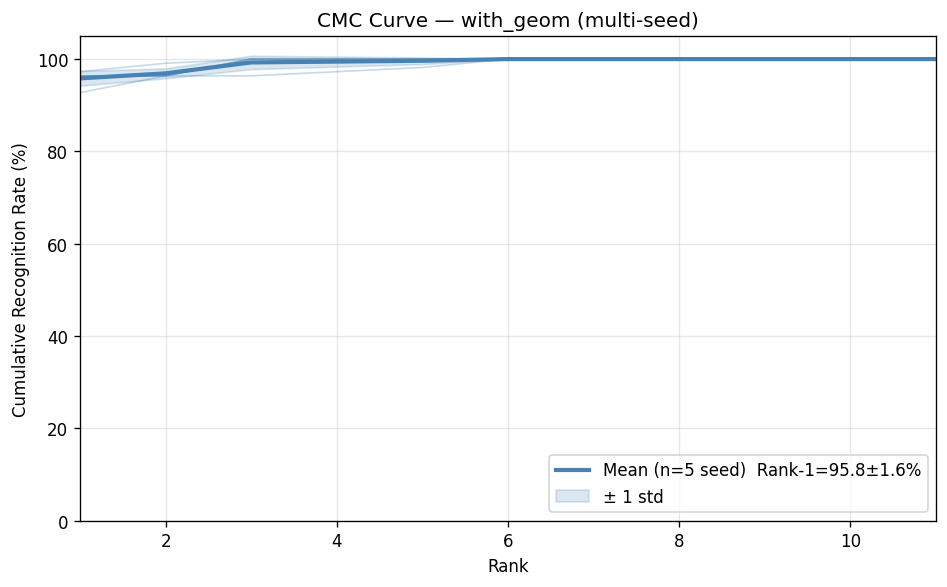

In [10]:
# CMC overlay multi-seed dengan pita mean ± stdcmc_matrix = np.stack([cmc_results[name]['cmc'] for name in CHECKPOINTS])  # (n_seed, max_rank)mean_cmc = cmc_matrix.mean(axis=0)std_cmc  = cmc_matrix.std(axis=0)ranks = np.arange(1, len(mean_cmc) + 1)fig, ax = plt.subplots(figsize=(8, 5))# Plot per-seed (transparan)for name, cmc_info in cmc_results.items():    ax.plot(ranks, cmc_info['cmc'] * 100, color='steelblue', alpha=0.3, lw=1)# Plot mean dengan pita stdax.plot(ranks, mean_cmc * 100, color='steelblue', lw=2.5,        label=f'Mean (n={len(CHECKPOINTS)} seed)  Rank-1={mean_cmc[0]*100:.1f}±{std_cmc[0]*100:.1f}%')ax.fill_between(ranks, (mean_cmc - std_cmc) * 100, (mean_cmc + std_cmc) * 100,                color='steelblue', alpha=0.2, label='± 1 std')ax.set_xlabel('Rank')ax.set_ylabel('Cumulative Recognition Rate (%)')ax.set_title(f'CMC Curve — with_geom (multi-seed)')ax.set_ylim(0, 105)ax.set_xlim(1, len(mean_cmc))ax.grid(True, alpha=0.3)ax.legend(loc='lower right')fig.tight_layout()cmc_path = OUTPUT_DIR / 'cmc_curve.png'fig.savefig(cmc_path, dpi=150)print(f'CMC curve disimpan: {cmc_path}')plt.show()

## 7. Confusion Matrix — Identifikasi Rank-1Per seed: matriks kesalahan klasifikasi 1:N (siapa salah ditebak sebagai siapa).Diagonal yang dominan = identifikasi konsisten.

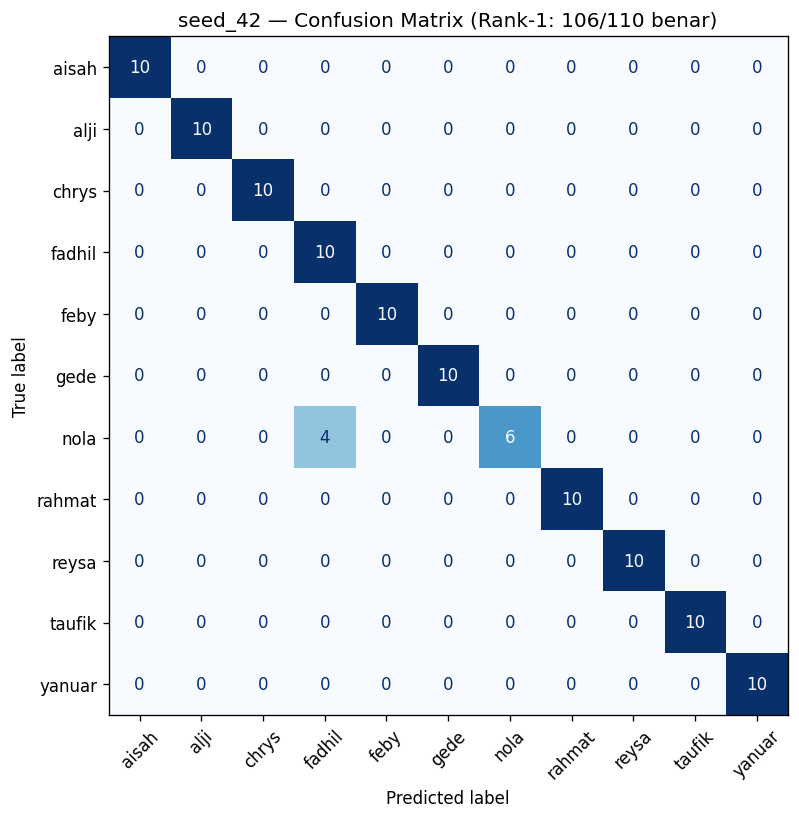

  confusion_matrix_seed_42.png disimpan


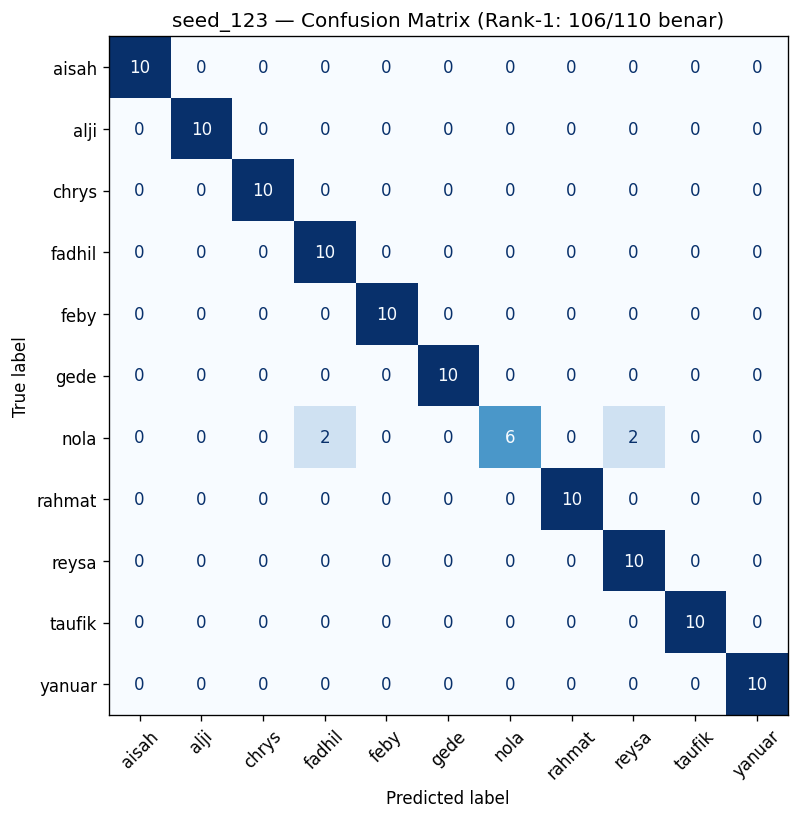

  confusion_matrix_seed_123.png disimpan


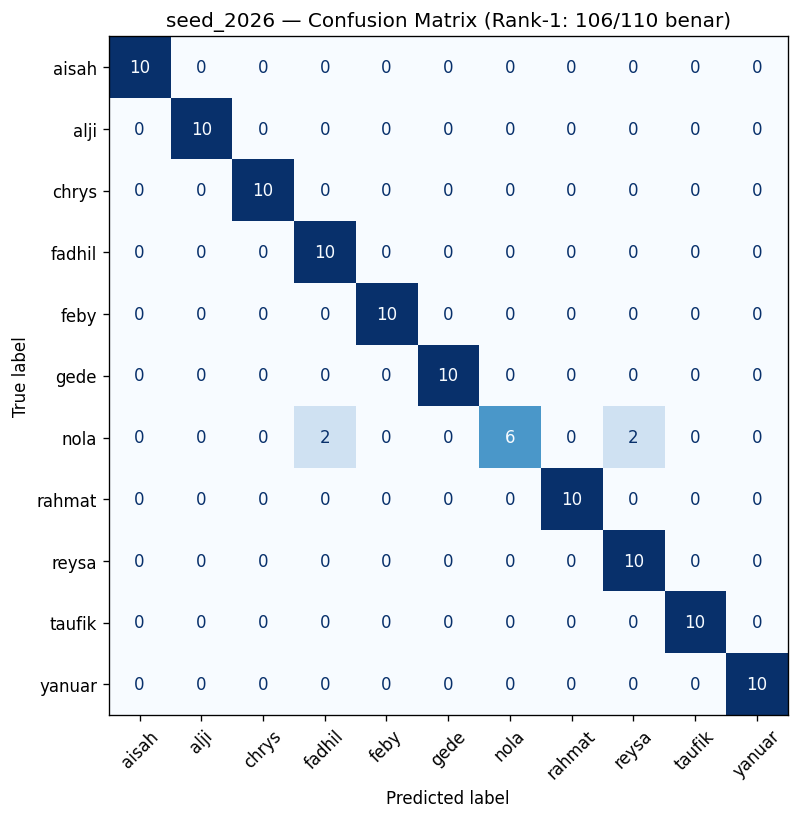

  confusion_matrix_seed_2026.png disimpan


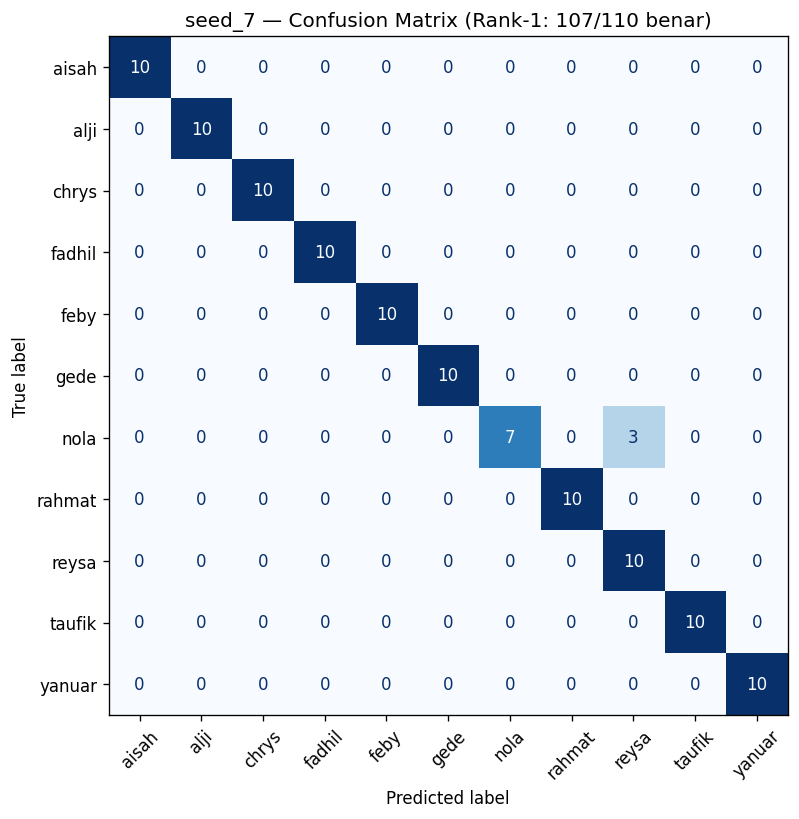

  confusion_matrix_seed_7.png disimpan


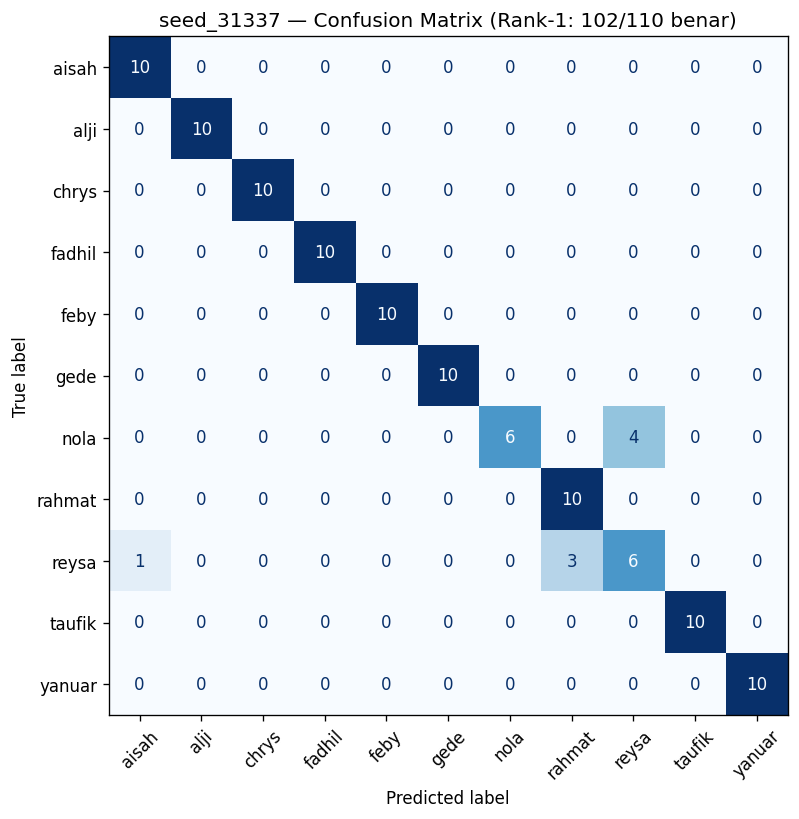

  confusion_matrix_seed_31337.png disimpan


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplayfor model_name, cmc_info in cmc_results.items():    true_labels = cmc_info['true_labels']    pred_labels = cmc_info['pred_labels']    all_labels_sorted = sorted(set(true_labels))    cm = confusion_matrix(true_labels, pred_labels, labels=all_labels_sorted)    n_subj = len(all_labels_sorted)    fig_size = max(6, n_subj * 0.7)    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels_sorted)    disp.plot(ax=ax, colorbar=False, xticks_rotation=45, cmap='Blues')    correct = np.trace(cm)    total   = cm.sum()    ax.set_title(f'{model_name} — Confusion Matrix (Rank-1: {correct}/{total} benar)')    fig.tight_layout()    cm_path = OUTPUT_DIR / f'confusion_matrix_{model_name}.png'    fig.savefig(cm_path, dpi=150, bbox_inches='tight')    plt.show()    print(f'  {cm_path.name} disimpan')

## 8. t-SNE Embedding SpaceVisualisasi 2D dari embedding 128-dim — apakah cluster per subjek terpisah dengan baik.Dipakai satu seed representatif (seed pertama).

t-SNE seed=42 — 121 embedding (11 gallery + 110 probe)


/tmp/ipykernel_2268/504625130.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(uniq))


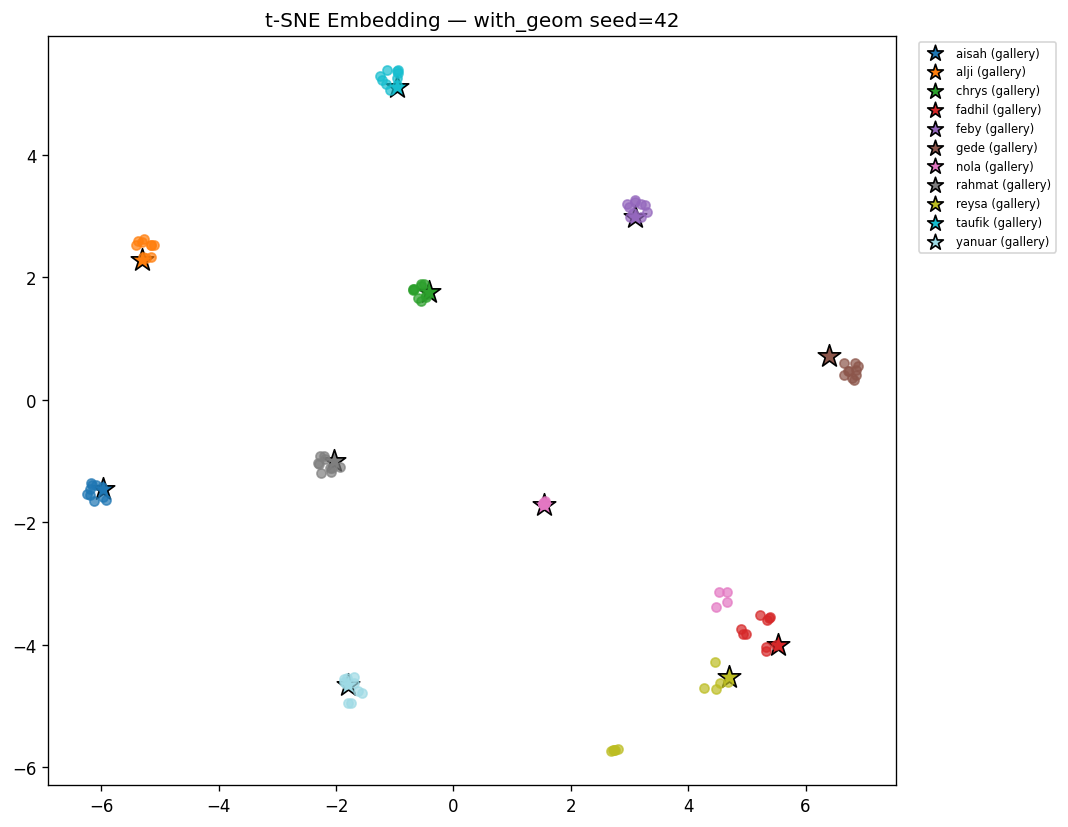

t-SNE disimpan: /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/tsne_seed_42.png


In [12]:
from sklearn.manifold import TSNEif all_seed_records:    rep_seed = all_seed_records[0]['seed']    npz = np.load(OUTPUT_DIR / f'embeddings_seed_{rep_seed}.npz', allow_pickle=True)    gallery_embs   = npz['gallery_embs']    gallery_labels_arr = npz['gallery_labels']    probe_embs     = npz['probe_embs']    probe_true     = npz['probe_true_labels']    # Gabungkan gallery + probe untuk t-SNE    all_embs   = np.vstack([gallery_embs, probe_embs])    all_labels = np.concatenate([gallery_labels_arr, probe_true])    # Map label string ke integer    uniq = sorted(set(all_labels.tolist()))    label_to_int = {l: i for i, l in enumerate(uniq)}    int_labels = np.array([label_to_int[l] for l in all_labels])    print(f't-SNE seed={rep_seed} — {len(all_embs)} embedding ({len(gallery_embs)} gallery + {len(probe_embs)} probe)')    perplexity = min(30, len(all_embs) - 1)    coords = TSNE(n_components=2, random_state=42, perplexity=perplexity).fit_transform(all_embs)    fig, ax = plt.subplots(figsize=(9, 7))    cmap = plt.cm.get_cmap('tab20', len(uniq))    n_gallery = len(gallery_embs)    for i, lbl in enumerate(uniq):        mask = int_labels == i        # Bedakan gallery (lingkaran besar) vs probe (titik kecil)        gal_mask  = mask.copy()        gal_mask[n_gallery:] = False        prb_mask  = mask.copy()        prb_mask[:n_gallery] = False        if gal_mask.any():            ax.scatter(coords[gal_mask, 0], coords[gal_mask, 1],                       c=[cmap(i)], marker='*', s=200, edgecolor='black',                       linewidth=1, label=f'{lbl} (gallery)')        if prb_mask.any():            ax.scatter(coords[prb_mask, 0], coords[prb_mask, 1],                       c=[cmap(i)], s=30, alpha=0.7)    ax.set_title(f't-SNE Embedding — with_geom seed={rep_seed}')    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=0.7)    fig.tight_layout()    tsne_path = OUTPUT_DIR / f'tsne_seed_{rep_seed}.png'    fig.savefig(tsne_path, dpi=150, bbox_inches='tight')    plt.show()    print(f't-SNE disimpan: {tsne_path}')

## 9. Verifikasi (Sekunder) — ROC, DET, Distribusi SimilarityMetrik verifikasi 1:1 untuk perbandingan tradisional. **Bukan metrik utama** untuk klaim tesis identifikasi 1:N.

ROC plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/roc_curves.png


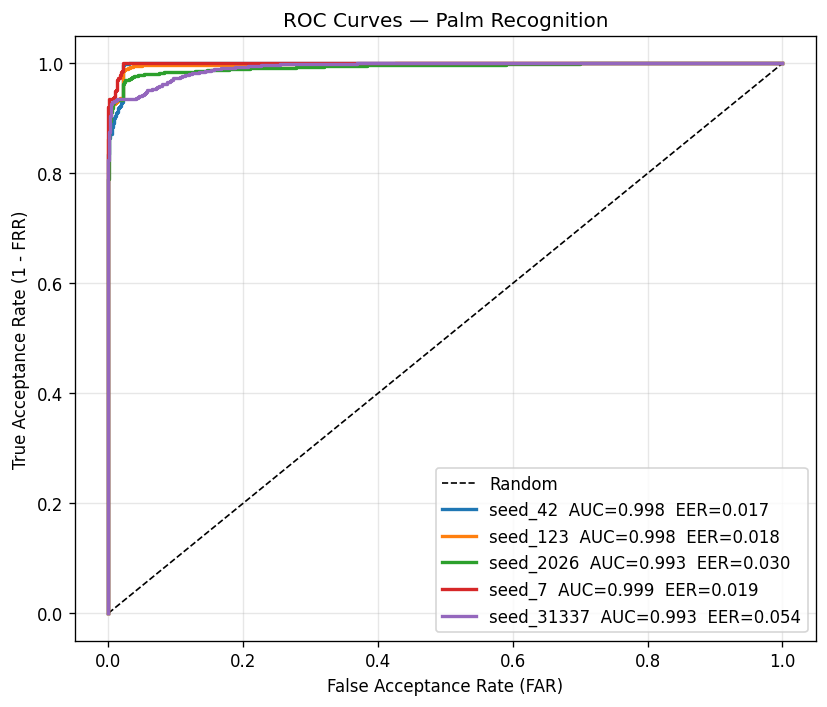

DET plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/det_curves.png


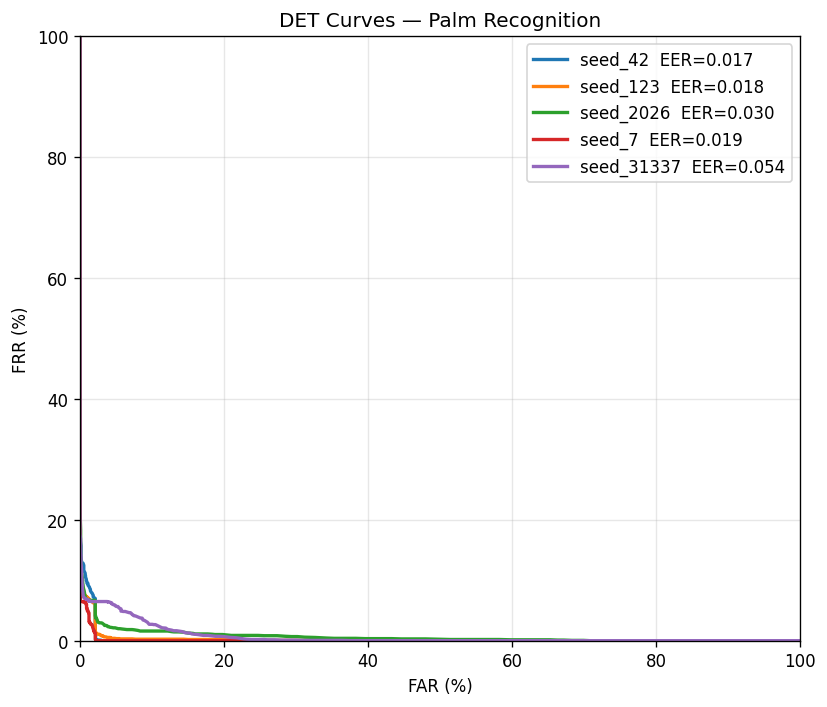

Similarity distribution plot saved to /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/sim_dist_seed_42.png


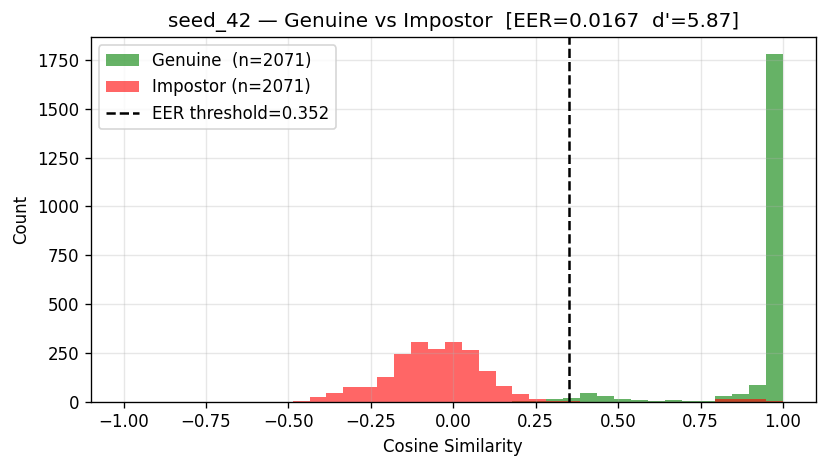

In [13]:
# ROC + DET multi-seedplot_roc(roc_data, save_path=OUTPUT_DIR / 'roc_curves.png')plot_det(det_data, save_path=OUTPUT_DIR / 'det_curves.png')# Distribusi similarity untuk seed representatifif all_results:    rep = all_results[0]    plot_similarity_dist(        rep['labels'], rep['scores'],        title=f"{rep['model']} — Genuine vs Impostor",        save_path=OUTPUT_DIR / f"sim_dist_{rep['model']}.png",    )

## 10. Per-Subject Similarity (Diagnostik)Rata-rata similarity genuine vs impostor per subjek. Berguna untuk mendeteksi subjek yang sulit dibedakan.

Preloading 219 sesi ke memori...
Preload selesai. Total pasangan: 4142


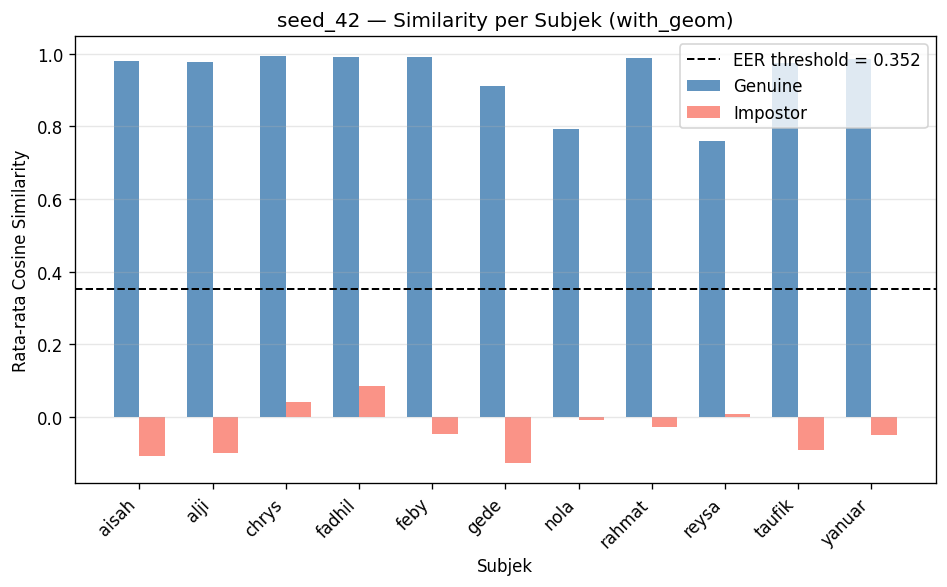

Per-subject similarity disimpan: /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830/per_subject_seed_42.png

Subjek            Gen Mean   Imp Mean   Separasi
--------------------------------------------------
aisah               0.9797    -0.1093     1.0890
alji                0.9785    -0.1014     1.0798
chrys               0.9930     0.0400     0.9530
fadhil              0.9905     0.0833     0.9072
feby                0.9915    -0.0481     1.0396
gede                0.9113    -0.1274     1.0386
nola                0.7924    -0.0080     0.8004
rahmat              0.9874    -0.0272     1.0146
reysa               0.7590     0.0083     0.7507
taufik              0.9751    -0.0920     1.0671
yanuar              0.9851    -0.0498     1.0349


In [14]:
def per_subject_similarity(pairs, scores, test_frames):    dir_to_label = {s: lbl for lbl, frames in test_frames.items() for s in frames}    per = {lbl: {'genuine': [], 'impostor': []} for lbl in test_frames}    for (dir_a, dir_b, lbl), score in zip(pairs, scores):        la = dir_to_label.get(dir_a); lb = dir_to_label.get(dir_b)        if la is None or lb is None:            continue        if lbl == 1.0:            per[la]['genuine'].append(score)        else:            per[la]['impostor'].append(score)            per[lb]['impostor'].append(score)    return {        s: {            'gen_mean':  float(np.mean(d['genuine']))  if d['genuine']  else 0.0,            'imp_mean':  float(np.mean(d['impostor'])) if d['impostor'] else 0.0,        } for s, d in per.items()    }if all_results:    rep = all_results[0]    rep_pairs = PalmPairDataset(        label_sessions=test_frames, n_points=N_POINTS,        sampling=SAMPLING, augment=None, normalizer=None, seed=SPLIT_SEED    ).pairs    per_subj = per_subject_similarity(rep_pairs, rep['scores'], test_frames)    subjects = sorted(per_subj.keys())    gen_means = [per_subj[s]['gen_mean'] for s in subjects]    imp_means = [per_subj[s]['imp_mean'] for s in subjects]    x = np.arange(len(subjects)); width = 0.35    fig, ax = plt.subplots(figsize=(max(8, len(subjects) * 0.7), 5))    ax.bar(x - width/2, gen_means, width, label='Genuine',  color='steelblue', alpha=0.85)    ax.bar(x + width/2, imp_means, width, label='Impostor', color='salmon',    alpha=0.85)    ax.axhline(rep['eer_threshold'], color='black', linestyle='--', lw=1.2,               label=f"EER threshold = {rep['eer_threshold']:.3f}")    ax.set_xticks(x)    ax.set_xticklabels(subjects, rotation=45, ha='right')    ax.set_xlabel('Subjek')    ax.set_ylabel('Rata-rata Cosine Similarity')    ax.set_title(f"{rep['model']} — Similarity per Subjek (with_geom)")    ax.legend()    ax.grid(axis='y', alpha=0.3)    fig.tight_layout()    sim_path = OUTPUT_DIR / f"per_subject_{rep['model']}.png"    fig.savefig(sim_path, dpi=150)    plt.show()    print(f'Per-subject similarity disimpan: {sim_path}')    print(f"\n{'Subjek':<15} {'Gen Mean':>10} {'Imp Mean':>10} {'Separasi':>10}")    print('-' * 50)    for s in subjects:        g = per_subj[s]['gen_mean']        i = per_subj[s]['imp_mean']        print(f"{s:<15} {g:>10.4f} {i:>10.4f} {g - i:>10.4f}")

In [15]:
print('=' * 64)print('EVALUASI SELESAI — with_geom (multi-seed)')print('=' * 64)print(f'Train timestamp  : {TRAIN_TIMESTAMP}')print(f'Eval  timestamp  : {EXPERIMENT_TIMESTAMP}')print(f'Output folder    : {OUTPUT_DIR}')print(f'Test fingerprint : {TEST_FINGERPRINT}')print(f'Seeds dievaluasi : {SEEDS}  (n={len(SEEDS)})')print()print('File yang dihasilkan:')for f in sorted(OUTPUT_DIR.iterdir()):    if f.is_file():        size_kb = f.stat().st_size / 1024        print(f'  {f.name:<45} {size_kb:>7.1f} KB')print()if all_seed_records:    rank1s    = np.array([r['rank1']         for r in all_seed_records])    rank5s    = np.array([r['rank5']         for r in all_seed_records])    eers      = np.array([r['eer']           for r in all_seed_records])    h_rank1s  = np.array([r.get('holdout_rank1', 0.0) for r in all_seed_records])    print('Ringkasan agregat:')    print(f'  [Test split]  Rank-1 : {rank1s.mean():.4f} ± {rank1s.std():.4f}')    print(f'                Rank-5 : {rank5s.mean():.4f} ± {rank5s.std():.4f}')    print(f'                EER    : {eers.mean():.4f} ± {eers.std():.4f}  (sekunder)')    if all_seed_records[0].get('holdout_n_probe', 0) > 0:        print(f'  [Holdout]     Rank-1 : {h_rank1s.mean():.4f} ± {h_rank1s.std():.4f}')print()print('Langkah berikutnya:')print('  1. Jalankan evaluate_no_geom.ipynb dengan SEEDS yang SAMA.')print('  2. Pastikan TEST_FINGERPRINT identik antar varian.')print('  3. Jalankan compare.ipynb untuk paired test + bootstrap CI.')

EVALUASI SELESAI — with_geom (multi-seed)
Train timestamp  : 20260516_210959
Eval  timestamp  : 20260516_223830
Output folder    : /content/drive/MyDrive/3DCNN/eval_results/with_geom/20260516_223830
Test fingerprint : 34b90906c80ab1eb
Seeds dievaluasi : [42, 123, 2026, 7, 31337]  (n=5)

File yang dihasilkan:
  cmc_curve.png                                    46.7 KB
  confusion_matrix_seed_123.png                    71.6 KB
  confusion_matrix_seed_2026.png                   72.6 KB
  confusion_matrix_seed_31337.png                  72.3 KB
  confusion_matrix_seed_42.png                     71.6 KB
  confusion_matrix_seed_7.png                      71.1 KB
  det_curves.png                                   55.5 KB
  embeddings_seed_123.npz                          57.8 KB
  embeddings_seed_2026.npz                         57.8 KB
  embeddings_seed_31337.npz                        57.9 KB
  embeddings_seed_42.npz                           57.9 KB
  embeddings_seed_7.npz                  

## 11. Ringkasan Output